# การวิเคราะห์และเตรียมข้อมูลสำหรับการจำแนกชนิดพืช (PlantCLEF 2026)

**เนื้อหาปฏิบัติการที่ส่ง :** การวิศวกรรมข้อมูล (Data Engineering)

---

**สมาชิก** 

6810405691 ปิยังกูร ปัสสาวะกัง บรรยาย หมู่ 1 ปฏิบัติ หมู่ 11 

6810405887 ศิวภูมิ พรหมจรรย์ บรรยาย หมู่ 1 ปฏิบัติ หมู่ 11

สมุดบันทึกนี้จัดทำขึ้นเพื่อใช้ในการวิเคราะห์โครงสร้างข้อมูลเบื้องต้นและวางแผนกระบวนการจัดเตรียมข้อมูล (Data Pipeline) สำหรับระบบต้นแบบในการจำแนกสายพันธุ์พืชตามโจทย์การแข่งขันทดสอบความแม่นยำทางคอมพิวเตอร์วิทัศน์



**วัตถุประสงค์ของระบบต้นแบบ**

1. เพื่อสร้างระบบประตูกลั่นกรองข้อมูลสำหรับตรวจสอบความถูกต้องทางกายภาพและเนื้อหาของภาพถ่ายแปลงพืชก่อนจะส่งเข้าสู่ระบบโมเดลวิเคราะห์สายพันธุ์หลัก

2. เพื่อลดภาระการประมวลผลและประหยัดทรัพยากรหน่วยประมวลผลกราฟิกบนเซิร์ฟเวอร์โดยการตัดภาพที่ใช้งานไม่ได้ออกทันที

3. เพื่อสร้างระบบแจ้งเตือนและให้ผลสะท้อนกลับแก่นักพฤกษศาสตร์ภาคสนามทันที เมื่อภาพถ่ายไม่ได้มาตรฐาน

4. เพื่อสร้างระบบมอนิเตอร์และจัดเก็บล็อกบน Hugging Face Spaces สำหรับวิเคราะห์ปัญหาของข้อมูลที่เกิดขึ้นในระบบ


## 1. แหล่งที่มา รูปแบบ และจำนวนข้อมูลในชุดข้อมูล

### 1.1 แหล่งที่มาของข้อมูลและช่องทางการได้มา
* **แหล่งที่มาของข้อมูล:** ข้อมูลในระบบนี้อ้างอิงและนำมาจากชุดข้อมูลของโครงการการแข่งขัน **PlantCLEF 2026** บนแพลตฟอร์ม Kaggle ซึ่งเข้าถึงได้ที่ลิงก์การแข่งขัน: [Kaggle PlantCLEF 2026](https://www.kaggle.com/competitions/plantclef-2026)
* **เจ้าของและผู้เผยแพร่:** ข้อมูลได้รับการสนับสนุนหลักจากเครือข่ายพฤกษศาสตร์พลเมืองของ **Pl@ntNet** ร่วมกับฐานข้อมูลความหลากหลายทางชีวภาพของ **GBIF** (Global Biodiversity Information Facility) และ **iNaturalist**
* **ช่องทางที่ได้มา:**
  1. **การมีส่วนร่วมของประชาชน (Crowdsourcing):** ภาพถ่ายทั้งหมดถูกบันทึกและส่งเข้ามาโดยสมาชิกผู้ใช้งานทั่วไปบนแอปพลิเคชัน Pl@ntNet จากทั่วโลก
  2. **ข้อมูลจากเซนเซอร์อัตโนมัติ (Sensor Data):** พิกัดตำแหน่งทางภูมิศาสตร์ (ละติจูด, ลองจิจูด) และความสูงจากระดับน้ำทะเล (Altitude) ถูกเก็บรวบรวมโดยอัตโนมัติผ่านเซนเซอร์ GPS ของสมาร์ทโฟน ณ ขณะที่ผู้ใช้งานถ่ายภาพพืช
  3. **การตรวจสอบคลาสป้ายกำกับ (Label Validation):** รหัสชนิดพืช (Species ID) ได้รับการจำแนกเบื้องต้นจากตัวแบบปัญญาประดิษฐ์ของแอปพลิเคชัน และผ่านการตรวจสอบความถูกต้องโดยกลุ่มผู้ใช้ที่มีประสบการณ์และนักพฤกษศาสตร์

### 1.2 รูปแบบไฟล์และโครงสร้างการจัดเก็บข้อมูลในปัจจุบัน
ชุดข้อมูลที่จัดเก็บอยู่ในพื้นที่ทำงานปัจจุบัน ประกอบด้วยรูปแบบและโครงสร้างดังนี้:
1. **ไฟล์ข้อมูลตาราง (Metadata):**
   * `PlantCLEF2024_single_plant_training_metadata.csv` (ขนาด 786 MB): ไฟล์ตารางชุดฝึกสอนหลัก ใช้ตัวคั่น `;` และคลุมข้อความด้วย `"` ประกอบด้วย 20 คอลัมน์ที่ระบุชื่อภาพ, ข้อมูลสายพันธุ์, พิกัด GPS และลิงก์ภาพสำหรับดาวน์โหลด
   * `PlantCLEF2025_test.csv` (ขนาด 137 KB): ไฟล์ตารางระบุแปลงสำรวจ (Quadrat) ของชุดทดสอบ ใช้ตัวคั่น `;` ประกอบด้วยคอลัมน์ `quadrat_id`, `author`, `date`, `license`
   * `species_ids.csv` (ขนาด 62 KB): ไฟล์รวบรวมรหัสชนิดพืชเป้าหมายที่ต้องใช้ทำนายในโมเดล ใช้ตัวคั่น `,` มี 1 คอลัมน์หลักคือ `species_id` สำหรับระบุชนิดพืชทั้งหมดที่จำเป็น
   * `pseudoquadrats_without_labels_complementary_training_set_urls.csv` (ขนาด 32 MB): ไฟล์รวม URL สำหรับดาวน์โหลดภาพฝึกฝนเพิ่มเติม
2. **ไฟล์รูปภาพหลัก (JPEG):**
   * รูปภาพสำหรับการทดสอบถูกเก็บแยกในไดเรกทอรี `PlantCLEF2025_test_images/PlantCLEF2025_test_images/` เป็นไฟล์ภาพชนิดบีบอัด **JPEG (.jpg)** โดยชื่อไฟล์จะสอดคล้องกับไอดีในตารางข้อมูลชุดทดสอบ

### 1.3 จำนวนตัวอย่างข้อมูลทั้งหมดในระบบ
จากการตรวจสอบระบบไฟล์ ได้ผลสรุปจำนวนข้อมูลดังนี้:
* **จำนวนเรคคอร์ดตารางฝึกสอนหลัก:** 1,408,033 แถว (ตรงกับภาพพืชเดี่ยว 1,408,033 ภาพ)
* **จำนวนภาพทดสอบจริงในไดเรกทอรี:** 2,105 ภาพ (ไฟล์ JPEG)
* **จำนวนแถวข้อมูลตารางชุดทดสอบ:** 2,105 แถว
* **จำนวนชนิดพืชเป้าหมายที่ต้องจำแนก:** 7,806 ชนิด (คลาสเป้าหมาย)
* **จำนวนลิงก์ URL รูปภาพฝึกสอนเพิ่มเติม:** 212,762 ลิงก์

In [1]:
import csv
import os

print("ตรวจสอบปริมาณข้อมูลในเครื่อง \n")

with open('species_ids.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    species_header = next(reader)
    species_ids = [row[0] for row in reader]
print(f"จำนวนคลาสพืชเป้าหมาย: {len(species_ids):,} ชนิด")

with open('PlantCLEF2025_test.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter=';')
    test_header = next(reader)
    test_rows = list(reader)
print(f"จำนวนตัวอย่างชุดทดสอบในตาราง: {len(test_rows):,} แถว (คอลัมน์: {test_header})")

test_img_dir = 'PlantCLEF2025_test_images/PlantCLEF2025_test_images'
if os.path.exists(test_img_dir):
    test_imgs = [fn for fn in os.listdir(test_img_dir) if fn.lower().endswith('.jpg')]
    print(f"จำนวนไฟล์ภาพทดสอบจริงในระบบ: {len(test_imgs):,} ไฟล์")
else:
    print("ไม่พบโฟลเดอร์ภาพถ่ายชุดทดสอบ")

with open('pseudoquadrats_without_labels_complementary_training_set_urls.csv', 'r', encoding='utf-8') as f:
    urls = [line.strip() for line in f if line.strip()]
print(f"จำนวนลิงก์ดาวน์โหลดภาพเสริม: {len(urls):,} ลิงก์")

train_row_count = 0
unique_species_in_train = set()
organ_distribution = {}
dataset_sources = {}

with open('PlantCLEF2024_single_plant_training_metadata.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter=';')
    train_header = next(reader)
    idx_species = train_header.index('species_id')
    idx_organ = train_header.index('organ')
    idx_dataset = train_header.index('dataset')
    
    for row in reader:
        train_row_count += 1
        unique_species_in_train.add(row[idx_species])
        organ = row[idx_organ]
        organ_distribution[organ] = organ_distribution.get(organ, 0) + 1
        dataset = row[idx_dataset]
        dataset_sources[dataset] = dataset_sources.get(dataset, 0) + 1

print(f"จำนวนข้อมูลฝึกสอนในตาราง: {train_row_count:,} แถว (คอลัมน์: {train_header})")
print(f"จำนวน Species ID ที่ตรวจพบในตารางฝึกสอนจริง: {len(unique_species_in_train):,} ชนิด")
print(f"การกระจายตัวของประเภทอวัยวะพืช: {organ_distribution}")
print(f"แหล่งที่มาของข้อมูลการฝึกสอน: {dataset_sources}")

ตรวจสอบปริมาณข้อมูลในเครื่อง 

จำนวนคลาสพืชเป้าหมาย: 7,806 ชนิด
จำนวนตัวอย่างชุดทดสอบในตาราง: 2,105 แถว (คอลัมน์: ['quadrat_id', 'author', 'date', 'license'])
จำนวนไฟล์ภาพทดสอบจริงในระบบ: 2,105 ไฟล์
จำนวนลิงก์ดาวน์โหลดภาพเสริม: 212,762 ลิงก์
จำนวนข้อมูลฝึกสอนในตาราง: 1,408,033 แถว (คอลัมน์: ['image_name', 'organ', 'species_id', 'obs_id', 'license', 'partner', 'author', 'altitude', 'latitude', 'longitude', 'gbif_species_id', 'species', 'genus', 'family', 'dataset', 'publisher', 'references', 'url', 'learn_tag', 'image_backup_url'])
จำนวน Species ID ที่ตรวจพบในตารางฝึกสอนจริง: 7,806 ชนิด
การกระจายตัวของประเภทอวัยวะพืช: {'leaf': 340852, 'fruit': 165855, 'bark': 88507, 'habit': 355732, 'flower': 389251, 'branch': 59632, 'scan': 8204}
แหล่งที่มาของข้อมูลการฝึกสอน: {'plantnet': 1102483, 'gbif': 305550}


## 2. เป้าหมายการทำนาย (Labels) และคุณลักษณะของข้อมูล (Features)

### 2.1 Label หรือ Target ที่ระบบต้องทำนาย
* **Target (เป้าหมาย):** รหัสชนิดพืชเป้าหมาย (**`species_id`**) เช่น รหัส `1396710` (ตรงกับชนิดพืช *Taxus baccata L.*)
* **ลักษณะของเป้าหมาย:** เป็นคลาสเชิงหมวดหมู่สำหรับการทำนายแบบ **Multi-class / Multi-label Classification** โดยมีขอบเขตคลาสที่เป็นไปได้ทั้งหมดจำนวน **7,806 คลาส**

### 2.2 Feature ที่จะป้อนให้โมเดลใช้ทำนาย
ข้อมูลที่จะป้อนเข้าสู่โมเดลเพื่อใช้จำแนกสายพันธุ์มีองค์ประกอบหลักดังนี้:
1. **ฟีเจอร์รูปภาพพฤกษศาสตร์ (Visual Features):** ค่าพิกเซลของรูปภาพ JPEG ของต้นพืชหรือแปลงสำรวจ โดยป้อนข้อมูลภาพผ่านเครือข่ายคอนโวลูชัน (CNN) หรือ Vision Transformer เพื่อสกัดเอาลักษณะเด่น เช่น โครงสร้างขอบใบ สีของกลีบดอก ลายเปลือกไม้ หรือกิ่งก้าน
2. **ฟีเจอร์ระบุส่วนของพืช (Organ Type):** คอลัมน์ `organ` ซึ่งระบุประเภทอวัยวะพืชในภาพถ่าย (เช่น ใบ `leaf`, ดอก `flower`, ผล `fruit`, เเปลือก `bark` หรือลักษณะทรงต้น `habit`) เพื่อช่วยในการแบ่งกลุ่มตัวอย่างหรือเสริมการทำงานของโมเดลในการจำแนกรูปฟอร์มพืช
3. **ข้อมูลพิกัดและสภาพภูมิศาสตร์ (Spatial Features):** ค่าละติจูด (`latitude`), ลองจิจูด (`longitude`) และความสูงชันระดับน้ำทะเล (`altitude`) เพื่อนำมาแปลงสัญญาณแบบ Geo-Embedding แล้วนำไปรวมกับฟีเจอร์รูปภาพ ซึ่งจะช่วยคัดกรองหรือเพิ่มความน่าจะเป็นของพืชในเขตพื้นที่จำกัดได้ตามหลักนิเวศวิทยาพืช
4. **โครงสร้างการจำแนกอนุกรมวิธาน (Taxonomic Hierarchy):** ข้อมูลคอลัมน์ `genus` (สกุล) และ `family` (วงศ์) เพื่อนำมาใช้เสริมในการเรียนรู้ของโมเดลแบบแบ่งระดับชั้น ช่วยลดการทำนายผิดพลาดข้ามวงศ์พืชที่มีลักษณะคล้ายคลึงกัน

In [2]:
print("ตัวอย่างแถวแรกของไฟล์ตารางฝึกสอนหลัก PlantCLEF2024_single_plant_training_metadata.csv ")
with open('PlantCLEF2024_single_plant_training_metadata.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter=';')
    header = next(reader)
    first_row = next(reader)
    row_dict = dict(zip(header, first_row))
    for key, val in row_dict.items():
        print(f"  {key:<20} -> {val}")

print("\n" + "="*70 + "\n")

print("ตัวอย่างแถวแรกของไฟล์ตารางชุดทดสอบ PlantCLEF2025_test.csv ")
with open('PlantCLEF2025_test.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter=';')
    header = next(reader)
    first_row = next(reader)
    row_dict = dict(zip(header, first_row))
    for key, val in row_dict.items():
        print(f"  {key:<20} -> {val}")

ตัวอย่างแถวแรกของไฟล์ตารางฝึกสอนหลัก PlantCLEF2024_single_plant_training_metadata.csv 
  image_name           -> 59feabe1c98f06e7f819f73c8246bd8f1a89556b.jpg
  organ                -> leaf
  species_id           -> 1396710
  obs_id               -> 1008726402
  license              -> cc-by-sa
  partner              -> 
  author               -> Gulyás Bálint
  altitude             -> 205.9261
  latitude             -> 47.5921600184
  longitude            -> 19.3628948779
  gbif_species_id      -> 5284517.0
  species              -> Taxus baccata L.
  genus                -> Taxus
  family               -> Taxaceae
  dataset              -> plantnet
  publisher            -> plantnet
  references           -> https://identify.plantnet.org/fr/k-southwestern-europe/observations/1008726402
  url                  -> https://bs.plantnet.org/image/o/59feabe1c98f06e7f819f73c8246bd8f1a89556b
  learn_tag            -> train
  image_backup_url     -> https://lab.plantnet.org/LifeCLEF/PlantCLEF20

## 3. การวิเคราะห์รูปภาพชุดทดสอบจากระบบ

จากการสแกนและประมวลผลไฟล์ภาพจริงจำนวน 2,105 ภาพในโฟลเดอร์ภาพชุดทดสอบ `PlantCLEF2025_test_images/PlantCLEF2025_test_images` พบลักษณะทางกายภาพที่สำคัญดังนี้:

### 3.1 ข้อมูลเชิงสถิติของขนาดและความละเอียดภาพ
* **ความกว้างเฉลี่ยของภาพ:** 2,776.97 พิกเซล (ขนาดตั้งแต่ 1,136 ถึง 4,108 พิกเซล)
* **ความสูงเฉลี่ยของภาพ:** 2,769.90 พิกเซล (ขนาดตั้งแต่ 1,136 ถึง 3,744 พิกเซล)
* **สัดส่วนมิติภาพ (Aspect Ratio):** ค่าเฉลี่ยสัดส่วนความกว้างต่อความสูงอยู่ที่ 1.0 ซึ่งบ่งชี้ว่าเกือบทุกรูปภาพมีสัดส่วนเป็นรูปสี่เหลี่ยมจัตุรัส ทำให้ง่ายต่อการปรับแต่งขนาด
* **ขนาดเฉลี่ยของไฟล์ภาพ:** 3.38 MB ต่อรูปภาพ (มีขนาดสูงสุดที่ 6.55 MB และต่ำสุดที่ 0.17 MB)

### 3.2 แผนการประมวลผลรูปภาพก่อนนำเข้าฝึกสอนโมเดล
1. **การปรับขนาดรูปภาพ (Image Resizing):** เนื่องจากความละเอียดของภาพถ่ายจากสมาร์ทโฟนเฉลี่ยอยู่ที่ประมาณ $2.7K$ พิกเซล หากนำภาพขนาดจริงป้อนเข้าสู่หน่วยความจำคอมพิวเตอร์เพื่อประมวลผลเชิงลึก จะทำให้ความเร็วในการเทรนลดลงและ VRAM บนการ์ดประมวลผล GPU ล้น จึงมีความจำเป็นต้องย่อรูปภาพลงให้มีขนาดคงที่ เช่น $224 \times 224 \times 3$ หรือ $384 \times 384 \times 3$ พิกเซล ก่อนส่งผ่านเข้าโมเดล
2. **การทำมาตรฐานสี (Color Normalization):** ต้องประมวลผลแปลงมิติภาพให้เป็น Tensor และลบด้วยค่าเฉลี่ยสี (RGB Mean Subtraction) พร้อมการเสริมข้อมูลภาพ (Data Augmentation) เช่น สุ่มหมุน สุ่มเอียง และกลับภาพแนวราบ เพื่อให้โมเดลจดจำชนิดพืชได้ท่ามกลางสภาพแวดล้อมที่แตกต่างกันในการเก็บข้อมูลจริง

การตรวจสอบขนาดและความละเอียดของไฟล์ภาพจริง 

จำนวนไฟล์รูปภาพชุดทดสอบ: 2,105 ไฟล์
ความกว้าง: เฉลี่ย 2776.97 px (ต่ำสุด: 1136, สูงสุด: 4108)
ความสูง: เฉลี่ย 2769.90 px (ต่ำสุด: 1136, สูงสุด: 3744)
สัดส่วนภาพเฉลี่ย: 1.00
ขนาดไฟล์: เฉลี่ย 3.38 MB (ต่ำสุด: 0.30 MB, สูงสุด: 7.47 MB)



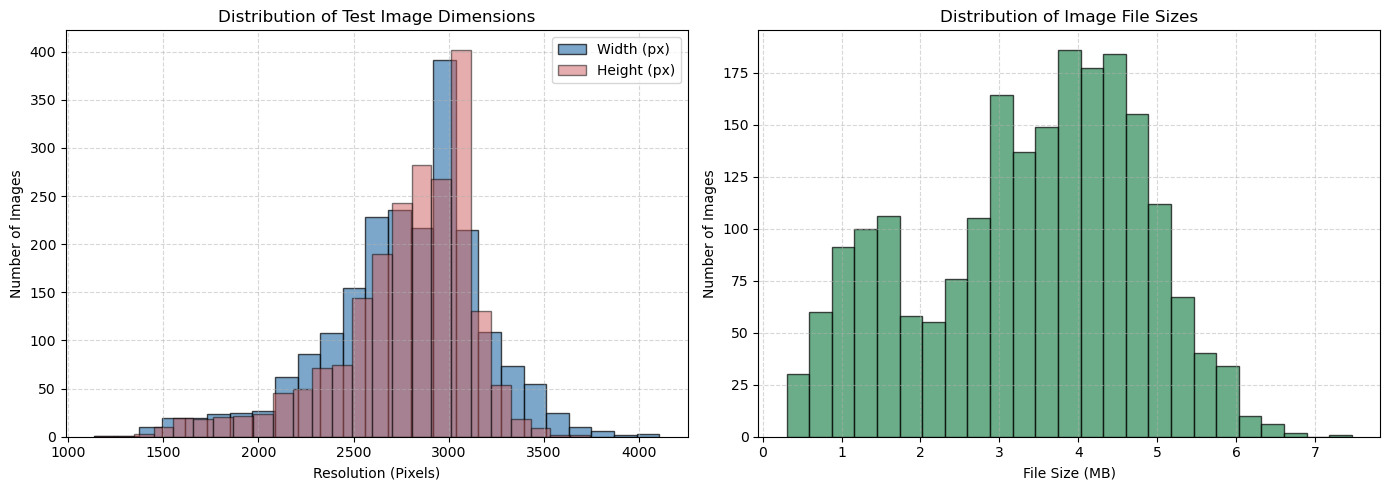

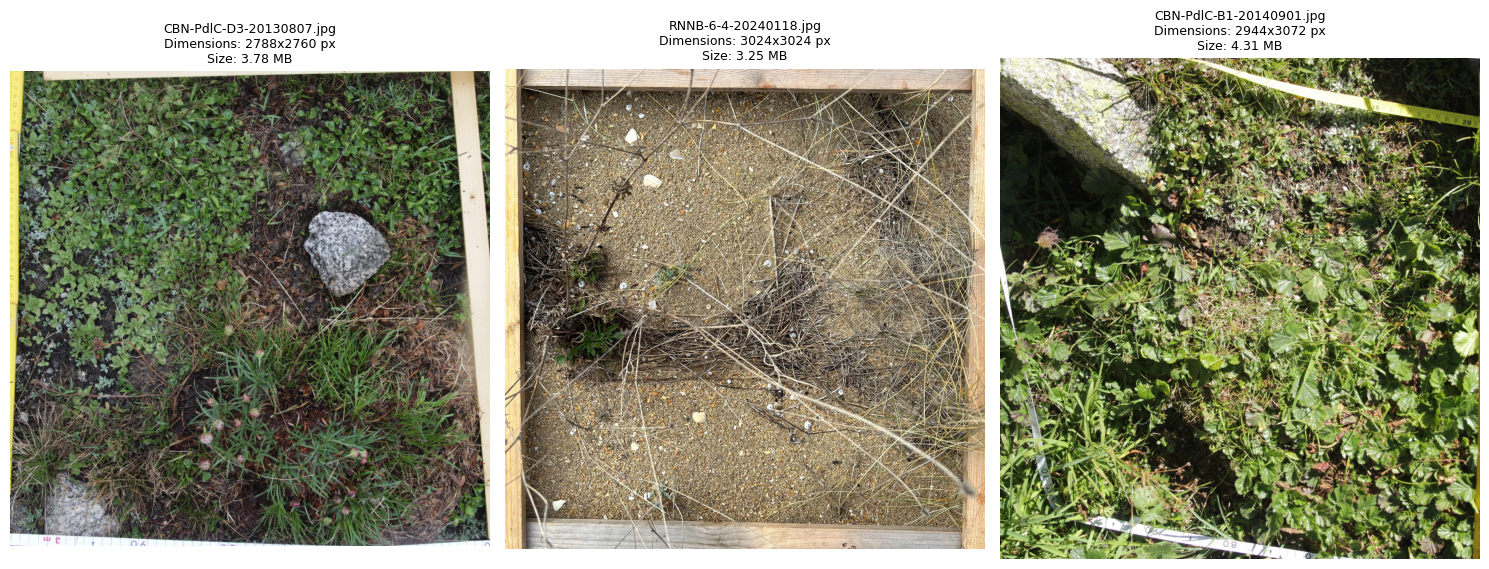

In [3]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print("การตรวจสอบขนาดและความละเอียดของไฟล์ภาพจริง \n")

img_dir = 'PlantCLEF2025_test_images/PlantCLEF2025_test_images'
img_paths = [os.path.join(img_dir, fn) for fn in os.listdir(img_dir) if fn.lower().endswith('.jpg')]

widths = []
heights = []
file_sizes = []
aspect_ratios = []

for p in img_paths:
    file_sizes.append(os.path.getsize(p) / (1024 * 1024))
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)

print(f"จำนวนไฟล์รูปภาพชุดทดสอบ: {len(img_paths):,} ไฟล์")
print(f"ความกว้าง: เฉลี่ย {np.mean(widths):.2f} px (ต่ำสุด: {min(widths)}, สูงสุด: {max(widths)})")
print(f"ความสูง: เฉลี่ย {np.mean(heights):.2f} px (ต่ำสุด: {min(heights)}, สูงสุด: {max(heights)})")
print(f"สัดส่วนภาพเฉลี่ย: {np.mean(aspect_ratios):.2f}")
print(f"ขนาดไฟล์: เฉลี่ย {np.mean(file_sizes):.2f} MB (ต่ำสุด: {min(file_sizes):.2f} MB, สูงสุด: {max(file_sizes):.2f} MB)\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=25, color='#4682B4', edgecolor='black', alpha=0.7, label='Width (px)')
axes[0].hist(heights, bins=25, color='#CD5C5C', edgecolor='black', alpha=0.5, label='Height (px)')
axes[0].set_title('Distribution of Test Image Dimensions')
axes[0].set_xlabel('Resolution (Pixels)')
axes[0].set_ylabel('Number of Images')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].hist(file_sizes, bins=25, color='#2E8B57', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Image File Sizes')
axes[1].set_xlabel('File Size (MB)')
axes[1].set_ylabel('Number of Images')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

sample_indices = [0, 1, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for idx, img_idx in enumerate(sample_indices):
    path = img_paths[img_idx]
    with Image.open(path) as img:
        axes[idx].imshow(img)
        filename = os.path.basename(path)
        axes[idx].set_title(f"{filename}\nDimensions: {img.width}x{img.height} px\nSize: {os.path.getsize(path)/(1024*1024):.2f} MB", fontsize=9)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 4. การเตรียมข้อมูล ข้อมูลที่ไม่ใช้ และรูปแบบการจัดเก็บทางเลือกสำหรับระบบต้นแบบ

### 4.1 กระบวนการประมวลผลและจัดเตรียมข้อมูลก่อนใช้งาน
1. **การดาวน์โหลดภาพและการเชื่อมโยงข้อมูลตาราง:** เนื่องจากรูปภาพส่วนใหญ่ของชุดข้อมูลฝึกฝนเก็บอยู่ในรูป URL บนเว็บโฮสต์ (`image_backup_url` และ `url`) ขั้นตอนแรกจึงต้องการเขียนสคริปต์ดาวน์โหลดข้อมูลแบบคู่ขนานที่มีระบบดาวน์โหลดซ้ำเมื่อพบข้อผิดพลาดของการเชื่อมต่อเครือข่าย เพื่อให้ได้ชุดข้อมูลภาพเก็บไว้ในเครื่องอย่างครบถ้วน
2. **การคัดกรองและปรับคุณภาพข้อมูลพิกัด GPS:** ข้อมูลตำแหน่งละติจูด ลองจิจูด และระดับความสูงจากผู้ใช้งานบางส่วนไม่ได้ถูกบันทึกหรือบันทึกพิกัดมาเป็นพิกัดไม่สมบูรณ์ (เช่น 0.0, 0.0) ต้องทำการจัดการแก้ไขเพื่อแทนที่พิกัดพืชด้วยค่าเฉลี่ยของพิกัดชนิดพืชในคลาสเป้าหมายเดียวกัน
3. **การแก้ปัญหาการแจกแจงคลาสพืชที่ไม่สมดุล (Class Imbalance):** ความหนาแน่นของข้อมูลชนิดพืชบางตัวมีจำนวนภาพสะสมสูงหลักร้อยภาพ ในขณะที่ชนิดหายากมีตัวอย่างภาพไม่กี่ภาพ จึงต้องประยุกต์ใช้วิธีคำนวณน้ำหนักการสูญเสียในระดับแบบจำลอง (Loss weight tuning) เพื่อช่วยปรับสมดุลความแม่นยำ

### 4.2 ข้อมูลที่ไม่ควรนำมาประมวลผลใช้งานในโมเดลต้นแบบ
มีข้อมูลหลายส่วนในไฟล์ตารางปัจจุบันที่ควรตัดออกและไม่สมควรนำมาป้อนให้กับแบบจำลองคอมพิวเตอร์วิทัศน์:
1. **ชื่อผู้ถ่ายภาพพืช (คอลัมน์ `author`):** เนื่องจากเป็นข้อมูลส่วนบุคคลเพื่อรักษาความเป็นส่วนตัวตามเงื่อนไขทางจรรยาบรรณวิชาการ และไม่มีความเกี่ยวข้องเชิงชีววิทยาของพืช หากนำเข้าประมวลผลอาจทำให้น้ำหนักโมเดลเอนเอียงไปตามสไตล์การถ่ายภาพของช่างภาพ
2. **รหัสการสังเกตการณ์ในฐานข้อมูลระบบ (คอลัมน์ `obs_id`):** เป็นเพียงเลขอ้างอิงทำรายการในการจัดเก็บข้อมูลเชิงสัมพันธ์ทั่วไป ไม่มีคุณสมบัติทางพฤกษศาสตร์ของพืชชนิดนั้น
3. **ประเภทสิทธิ์การใช้งาน (คอลัมน์ `license` และพันธมิตรผู้รวบรวม `partner`):** ข้อมูลกฎหมายลิขสิทธิ์และแท็กระบุธุรการระบบ (`learn_tag` และ `dataset`)
4. **สายอักขระลิงก์ URL อ้างอิงภาพ (คอลัมน์ `references` และ `url`):** เป็นลิงก์สำหรับเว็บไซต์ประชาสัมพันธ์และเว็บอ้างอิงภาพ ไม่ใช่คุณลักษณะทางชีวภาพของพืช

### 4.3 รูปแบบสถาปัตยกรรมการจัดเก็บข้อมูลทางเลือกที่ดีกว่า
1. **การจัดเก็บข้อมูลตารางในรูปไฟล์ Apache Parquet:** ปัจจุบันไฟล์ตารางข้อมูลขนาดใหญ่ประมาณ 786 MB ถูกเก็บในรูปแบบ CSV ซึ่งส่งผลให้ใช้เวลาในการโหลดข้อมูลยาวนานและต้องทำฟังก์ชันแปลงชนิดตัวแปรใหม่ การเปลี่ยนไปจัดเก็บในฟอร์แมต **Parquet** (Columnar format) จะทำให้ไฟล์ถูกบีบอัดจนเหลือขนาดน้อยกว่า 80 MB และระบุประเภทข้อมูลไว้ได้เลยตั้งแต่ต้น
2. **การแปลงนามสกุลรูปภาพเป็น WebP:** เพื่อประหยัดเนื้อที่การจัดเก็บดิสก์และแบนด์วิดท์ในการรับส่งข้อมูลระหว่างการเรียกใช้งาน การใช้ภาพประเภทบีบอัดประสิทธิภาพสูงอย่าง **WebP** จะลดขนาดข้อมูลลงได้ราว 30% โดยไม่มีผลเสียต่อคุณลักษณะความคมชัด
3. **การแพ็กข้อมูลเข้าไบนารีระบบคอนเทนเนอร์ LMDB หรือ TFRecord:** การดึงภาพถ่ายย่อยๆ จากฮาร์ดดิสก์ในการฝึกอบรมแบบจำลองจำนวนมากกว่า 1.4 ล้านครั้งสร้างภาระและคอขวดให้ระบบทางกายภาพ การรวมแพ็กภาพพร้อมคลาสเป้าหมายเป็นไบนารีสตรีมมิ่งไฟล์ใหญ่ เช่น **LMDB** (สำหรับ PyTorch) หรือ **TFRecord** (สำหรับ TensorFlow) จะทำให้ตัวควบคุมหน่วยความจำสามารถส่งถ่ายข้อมูลเข้า GPU ได้ไหลลื่นเต็มความจุประสิทธิภาพสูงสุด

## 5. บทสรุปและแหล่งอ้างอิงของระบบต้นแบบ

### บทสรุปของการวิเคราะห์ชุดข้อมูล
การสร้างระบบต้นแบบจำแนกชนิดพืชตามโจทย์การแข่งขันทดสอบความถูกต้อง PlantCLEF 2026 จำเป็นต้องอาศัยการล้างข้อมูลตารางที่ไม่เกี่ยวข้องอย่างละเอียดยิบ และต้องการการบำบัดขนาดของข้อมูลรูปภาพทดสอบจริงซึ่งมีความละเอียดสูง (~2.7K) โดยการย่อขนาดเพื่อหลีกเลี่ยงปัญหาหน่วยความจำของคอมพิวเตอร์เต็ม รวมทั้งการปรับเปลี่ยนฟอร์แมตจัดเก็บเช่น Parquet และ LMDB เพื่อให้เกิดความเร็วในการป้อนข้อมูลเข้าหน่วยความจำประมวลผลสูงสุดตามโครงสร้างแผนการทำงาน

### แหล่งอ้างอิงสำหรับการจำลองข้อมูล
1. **Kaggle PlantCLEF 2026 Competition Data:** [https://www.kaggle.com/competitions/plantclef-2026](https://www.kaggle.com/competitions/plantclef-2026)
2. **Pl@ntNet Portal:** [https://plantnet.org/](https://plantnet.org/)
3. **Apache Parquet Columnar Storage Specification:** [https://parquet.apache.org/](https://parquet.apache.org/)

**การมีส่วนร่วมของสมาชิกแต่ละคนในกลุ่ม (แต่ละคนทำอะไรบ้าง)**


6810405691 ปิยังกูร ปัสสาวะกัง : ร่วมกันคิดโปรเจค , ตรวจสอบ Data เช็คข้อมูล Export File 


6810405887 ศิวภูมิ พรหมจรรย์ : ร่วมกันคิดโปรเจค , หา Data หาข้อมูลเพิ่มเติม ตรวจสอบความถูกต้อง


**การเปิดเผยการใช้งาน AI (AI Disclosure):** สมุดบันทึกนี้มีการใช้งานเครื่องมือปัญญาประดิษฐ์เพื่อช่วยเรียบเรียงคำอธิบายบางส่วนและร่างสคริปต์ Python สำหรับตรวจสอบข้อมูลเชิงสถิติเบื้องต้น โดยสมาชิกในกลุ่มได้ทำการทบทวน ตรวจสอบความถูกต้องของข้อมูลทั้งหมด และดำเนินการรันผลลัพธ์เพื่อใช้ประกอบการส่งรายงาน